# **Transformers Fine-Tune With Hugging Face**

#### **Import Libraries**

In [48]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.nn import CrossEntropyLoss
import time
from torchmetrics import Accuracy


#### **Define and Import Dataset** 

In [5]:
dataset = load_dataset("yelp_review_full")
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [6]:
train_dataset = dataset['train']
test_dataset = dataset['test']


In [7]:
train_dataset[0]

{'label': 4,
 'text': "dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens and you need surgery; and you can get referrals to see specialists without having to see him first.  really, what more do you need?  i'm sitting here trying to think of any complaints i have about him, but i'm really drawing a blank."}

Decrease the amount of data inorder to reduce the training time. 

**warining**: train with less data, the model accuracy will be lower

In [8]:
new_train_dataset = train_dataset.select([i for i in range(1000)])
new_test_dataset = test_dataset.select([i for i in range(500)])

In [9]:
for i in range (20):
    print(new_train_dataset[i])

{'label': 4, 'text': "dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens and you need surgery; and you can get referrals to see specialists without having to see him first.  really, what more do you need?  i'm sitting here trying to think of any complaints i have about him, but i'm really drawing a blank."}
{'label': 1, 'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  Y

### **Define Tokenization**

In [10]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [11]:
sample_token = tokenizer(new_train_dataset[0]["text"])
sample_token

{'input_ids': [101, 173, 1197, 119, 2284, 2953, 3272, 1917, 178, 1440, 1111, 1107, 170, 1704, 22351, 119, 1119, 112, 188, 3505, 1105, 3123, 1106, 2037, 1106, 1443, 1217, 10063, 4404, 132, 1119, 112, 188, 1579, 1113, 1159, 1107, 3195, 1117, 4420, 132, 1119, 112, 188, 6559, 1114, 170, 1499, 118, 23555, 2704, 113, 183, 9379, 114, 1134, 1139, 2153, 1138, 3716, 1106, 1143, 1110, 1304, 1696, 1107, 1692, 1380, 5940, 1105, 1128, 1444, 6059, 132, 1105, 1128, 1169, 1243, 5991, 16179, 1106, 1267, 18137, 1443, 1515, 1106, 1267, 1140, 1148, 119, 1541, 117, 1184, 1167, 1202, 1128, 1444, 136, 178, 112, 182, 2807, 1303, 1774, 1106, 1341, 1104, 1251, 11344, 178, 1138, 1164, 1140, 117, 1133, 178, 112, 182, 1541, 4619, 170, 9153, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

##### Function to tokenize the dataset texts  

In [12]:
def text_tokenization (dataset):
    return tokenizer(dataset["text"], padding='max_length', truncation=True)

In [13]:
tokenized_train_dataset = new_train_dataset.map(text_tokenization,batched=True)
tokenized_test_dataset = new_test_dataset.map(text_tokenization, batched=True)

In [14]:
tokenized_train_dataset[0]

{'label': 4,
 'text': "dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens and you need surgery; and you can get referrals to see specialists without having to see him first.  really, what more do you need?  i'm sitting here trying to think of any complaints i have about him, but i'm really drawing a blank.",
 'input_ids': [101,
  173,
  1197,
  119,
  2284,
  2953,
  3272,
  1917,
  178,
  1440,
  1111,
  1107,
  170,
  1704,
  22351,
  119,
  1119,
  112,
  188,
  3505,
  1105,
  3123,
  1106,
  2037,
  1106,
  1443,
  1217,
  10063,
  4404,
  132,
  1119,
  112,
  188,
  1579,
  1113,
  1159,
  1107,
  3195,
  1117,
  4420,
  132,
  1119,
  112,
  188,
  6559,
  1114,
  170,
  1499,
  118,
  23555,
  2704,
  113,
  183,
  9379,
  114,
  1

In [15]:
for i in range (10):
    print(tokenized_train_dataset[i])

{'label': 4, 'text': "dr. goldberg offers everything i look for in a general practitioner.  he's nice and easy to talk to without being patronizing; he's always on time in seeing his patients; he's affiliated with a top-notch hospital (nyu) which my parents have explained to me is very important in case something happens and you need surgery; and you can get referrals to see specialists without having to see him first.  really, what more do you need?  i'm sitting here trying to think of any complaints i have about him, but i'm really drawing a blank.", 'input_ids': [101, 173, 1197, 119, 2284, 2953, 3272, 1917, 178, 1440, 1111, 1107, 170, 1704, 22351, 119, 1119, 112, 188, 3505, 1105, 3123, 1106, 2037, 1106, 1443, 1217, 10063, 4404, 132, 1119, 112, 188, 1579, 1113, 1159, 1107, 3195, 1117, 4420, 132, 1119, 112, 188, 6559, 1114, 170, 1499, 118, 23555, 2704, 113, 183, 9379, 114, 1134, 1139, 2153, 1138, 3716, 1106, 1143, 1110, 1304, 1696, 1107, 1692, 1380, 5940, 1105, 1128, 1444, 6059, 132, 

##### **Format the Datasets**

In [16]:
tokenized_train_dataset = tokenized_train_dataset.remove_columns(["text"])
tokenized_test_dataset = tokenized_test_dataset.remove_columns(["text"])

tokenized_train_dataset = tokenized_train_dataset.rename_column("label", "labels")
tokenized_test_dataset = tokenized_test_dataset.rename_column("label", "labels")

#convert lists into tensors
tokenized_train_dataset.set_format("torch")
tokenized_test_dataset.set_format("torch")

In [17]:
tokenized_train_dataset[2]

{'labels': tensor(3),
 'input_ids': tensor([  101, 18511,  1280,  1106,  1987,   119, 20029,  1111,  1166,  1275,
          1201,   119,   146,  1341,   146,  1108,  1141,  1104,  1117,  2198,
          4420,  1165,  1119,  1408,  1120,   150,  3048, 14666,   119,  1124,
           112,   188,  1151,  1632,  1166,  1103,  1201,  1105,  1110,  1541,
          1155,  1164,  1103,  1992,  3439,   119,  1135,  1110,  1272,  1104,
          1140,   117,  1136,  1139,  1208,  1393,   176,  5730,  1987,   119,
          2392,  5792,   117,  1115,   146,  1276,  1149,   146,  1138, 20497,
         12725,  7540,   119,  1124, 16001,  1155,  6665,  1114,  1128,  1105,
          1110,  1304,  5351,  1105,  4287,   119,  1124,  2144,   112,   189,
          3942,  1105,  4390,  1155,  1103,  1268,  3243,   119,  6424, 17213,
          1105,  3349,  1106,  1129,  2023,  1107,  1103,  7812,  1113,  1451,
          7631,  1104,  1240,  2657,  2332,  1105,  1240,  1297,   119,   102,
             0,  

In [18]:
for i in range (10):
    print(tokenized_train_dataset[i])

{'labels': tensor(4), 'input_ids': tensor([  101,   173,  1197,   119,  2284,  2953,  3272,  1917,   178,  1440,
         1111,  1107,   170,  1704, 22351,   119,  1119,   112,   188,  3505,
         1105,  3123,  1106,  2037,  1106,  1443,  1217, 10063,  4404,   132,
         1119,   112,   188,  1579,  1113,  1159,  1107,  3195,  1117,  4420,
          132,  1119,   112,   188,  6559,  1114,   170,  1499,   118, 23555,
         2704,   113,   183,  9379,   114,  1134,  1139,  2153,  1138,  3716,
         1106,  1143,  1110,  1304,  1696,  1107,  1692,  1380,  5940,  1105,
         1128,  1444,  6059,   132,  1105,  1128,  1169,  1243,  5991, 16179,
         1106,  1267, 18137,  1443,  1515,  1106,  1267,  1140,  1148,   119,
         1541,   117,  1184,  1167,  1202,  1128,  1444,   136,   178,   112,
          182,  2807,  1303,  1774,  1106,  1341,  1104,  1251, 11344,   178,
         1138,  1164,  1140,   117,  1133,   178,   112,   182,  1541,  4619,
          170,  9153,   119, 

In [19]:
tokenized_train_dataset[0].keys()

dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])

In [20]:
num_labels = len(set([new_train_dataset[i]["label"] for i in range(len(new_train_dataset))]))
num_labels

5

### **Define Dataloaders**

In [39]:
train_dataloader = DataLoader(tokenized_train_dataset,shuffle=True, batch_size=4, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(tokenized_test_dataset, shuffle=False, batch_size=4,num_workers=2,pin_memory=True)

### **Train the Model**

In [40]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-cased",num_labels = num_labels)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2843.11it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint

#### **Define Model Parameters**

In [41]:
optimizer = AdamW(model.parameters(),lr=5e-4)

num_epochs = 10

total_steps = num_epochs * len(new_train_dataset)

lr_scheduler = LambdaLR(optimizer, lr_lambda= lambda current_step: (1-current_step/total_steps))

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [44]:
device.type

'cuda'

#### **Define Train Function** 

In [45]:
def model_train (model:AutoModelForSequenceClassification, dataloader: DataLoader, num_epochs = num_epochs):
    
    total_loss = []

    model.train()
    
    start_time = time.time()
    
    for epoch in tqdm(range(num_epochs)):
        
        loss = 0
        
        for batch in dataloader:
            
            optimizer.zero_grad()
            batch = {k: v.to(device) for k,v in batch.items()}
            output = model(**batch)
            loss_batch = output.loss
            
            loss_batch.backward()
            
            optimizer.step()
            lr_scheduler.step()
            
            loss += loss_batch.item()
        total_loss.append(loss / len(dataloader))
    
    end_time = time.time()
    
    print(f"Training Duration: {end_time-start_time}")
      
    return total_loss

In [46]:
train_loss = model_train(model,train_dataloader) 

100%|██████████| 10/10 [32:14<00:00, 193.48s/it]

Training Duration: 1934.8151504993439


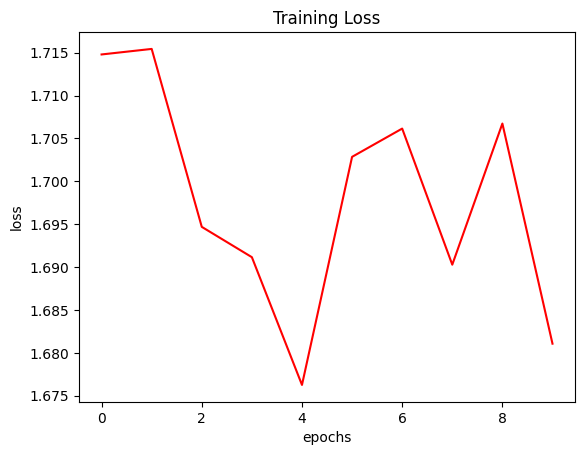

In [47]:
plt.plot(train_loss, color = "red")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Training Loss")
plt.show()

### **Model Evaluation**

In [60]:
def model_eval(model:AutoModelForSequenceClassification,eval_dataloader:DataLoader):
    
    model.eval()
    accuracy_metrices = Accuracy(task='multiclass',num_classes=num_labels).to(device)
    
    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k,v in batch.items()}
            
            predictions = model(**batch)
            logits = predictions.logits
            outputs = torch.argmax(logits, dim = -1)
            
            accuracy_metrices(outputs, batch["labels"])
            
    #compute the accuracy using metrices
    accuracy = accuracy_metrices.compute()

    print("accuracy:", accuracy.item())
    return accuracy.item()
            
                 

In [61]:
accuracy_metrices = Accuracy(task='multiclass',num_classes=num_labels).to(device)
accuracy_metrices

MulticlassAccuracy()

In [62]:
accuracy = model_eval(model, test_dataloader)

accuracy: 0.23800000548362732


In [64]:
# save the model
torch.save(model, "classification_model_pretrained_hf.pt")